In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import qiskit
import glob
import pickle
import scipy.linalg as linalg

from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator

import dqs

matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"


In [3]:
from qiskit.synthesis import SuzukiTrotter

pte = SuzukiTrotter(reps=1)


In [4]:
from qiskit.circuit.library import PauliEvolutionGate

pauli = Pauli('Y')
pauli_op = PauliEvolutionGate(pauli, time=1.0)


In [5]:
circ_op = pauli_op


In [6]:
qc = QuantumCircuit(1)
qc.append(pauli_op, [0])
qc.draw()

┌───────────────┐
q: ┤ exp(-it Y)(1) ├
   └───────────────┘

In [7]:
d = dqs.quantum_dynamics.Dynamics("EXACT: (1)Y + (1)X")
circ = d.gen_circuit(1, r=2, barriers=False)
print(circ)


    ┌─────┐┌───┐┌───────┐┌───┐┌───┐┌───┐┌───────┐┌───┐┌─────┐┌───┐┌───────┐»
q0: ┤ Sdg ├┤ H ├┤ Rz(1) ├┤ H ├┤ S ├┤ H ├┤ Rz(1) ├┤ H ├┤ Sdg ├┤ H ├┤ Rz(1) ├»
    └─────┘└───┘└───────┘└───┘└───┘└───┘└───────┘└───┘└─────┘└───┘└───────┘»
«    ┌───┐┌───┐┌───┐┌───────┐┌───┐
«q0: ┤ H ├┤ S ├┤ H ├┤ Rz(1) ├┤ H ├
«    └───┘└───┘└───┘└───────┘└───┘


In [8]:
dqs_circuit_unitary = d.getCircuitUnitary()
print(dqs_circuit_unitary)

[[ 0.1862656 -0.35403672j -0.64805984-0.64805984j]
 [ 0.64805984-0.64805984j  0.1862656 +0.35403672j]]


In [9]:
sparse_pauli_op = SparsePauliOp.from_list([('Y', 1.0), ('X', 1.0)])
print(sparse_pauli_op)


SparsePauliOp(['Y', 'X'],
              coeffs=[1.+0.j, 1.+0.j])


In [10]:
pauli_sum_op = SparsePauliOp.from_list([('Y', 1.0), ('X', 1.0)])
print(pauli_sum_op)
exact_unitary = np.array(linalg.expm(-1j * pauli_sum_op.to_matrix()), dtype=complex)
print(exact_unitary)
print(pauli_sum_op.to_matrix())
print(type(pauli_sum_op.to_matrix().dtype))

SparsePauliOp(['Y', 'X'],
              coeffs=[1.+0.j, 1.+0.j])
[[ 0.15594369+0.j       -0.698456  -0.698456j]
 [ 0.698456  -0.698456j  0.15594369+0.j      ]]
[[0.+0.j 1.-1.j]
 [1.+1.j 0.+0.j]]
<class 'numpy.dtypes.Complex128DType'>


In [11]:
d.processFidelity(exact_unitary, dqs_circuit_unitary)

0.873

In [12]:
d.compute2Norm(exact_unitary, dqs_circuit_unitary)

np.float64(0.3624099347864014)

In [13]:
d.mathematicaFidelity(exact_unitary, dqs_circuit_unitary)

np.float64(0.9343295186845596)

In [ ]:
def get_pauli_sum_op(H, coeff=1.0):
    H_as_list = [(term[1], term[0] * coeff) for term in H]
    return SparsePauliOp.from_list(H_as_list)

def get_exact_unitary(H):
    pauli_sum_op = get_pauli_sum_op(H)
    return np.array(linalg.expm(-1j * pauli_sum_op.to_matrix()), dtype=complex)

def _build_evolution_operator(H, t):
    if isinstance(H[0][1], str):
        H = [(term[1], term[0]) for term in H]
    pauli_sum_op = get_pauli_sum_op(H, coeff=t)
    unitary = linalg.expm(-1j * pauli_sum_op.to_matrix())
    return Operator(unitary)

def time_simulation(Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01):
    expectations = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        if callable(Hfunc):
            H = Hfunc(t)
        else:
            H = Hfunc
        evolution_operator = _build_evolution_operator(H, t)
        final_state = init_state.evolve(evolution_operator)
        expectations.append(final_state.expectation_value(meas_op).real)
    return expectations, time


In [15]:
H = [(1, 'XZ'), (1, 'XX'), (1, 'ZX')]
r_vals = [1, 2, 4, 6, 8, 10]

lex_fidelity = fidelity_over_r(H, 'lex', r_vals)
mct_fidelity = fidelity_over_r(H, 'mc_tsp', r_vals)
mag_fidelity = fidelity_over_r(H, 'mag', r_vals)

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-3.84139704e-08 -3.84139704e-08 -2.14644078e-08 -2.14644078e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.842715e-08 -2.842715e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.56178026e-08 -4.56178026e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.14644078e-08 -2.14644078e-08 -1.36128586e-08 -1.36128586e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [1.97156453e-08 1.97156453e-08 2.99990497e-08 2.99990497e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-3.84139704e-08 -3.84139704e-08 -2.14644078e-08 -2.14644078e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.842715e-08 -2.842715e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.56178026e-08 -4.56178026e-08]


Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.14644078e-08 -2.14644078e-08 -1.36128586e-08 -1.36128586e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [1.97156453e-08 1.97156453e-08 2.99990497e-08 2.99990497e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-3.78345015e-08 -3.78345015e-08 -2.20438767e-08 -2.20438767e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-1.88276656e-08 -1.88276656e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [1.41027152e-08 1.41027152e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-6.03501018e-08 -6.03501018e-08 -1.07317382e-08 -1.07317382e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [1.98779899e-08 1.98779899e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-1.66882644e-08 -1.66882644e-08  2.43212067e-08  2.43212067e-08]


lex: [0.4633, 0.9206, 0.9835, 0.9929, 0.9961, 0.9975]
mc_tsp: [0.4633, 0.9206, 0.9835, 0.9929, 0.9961, 0.9975]
mag: [0.1513, 0.6947, 0.9148, 0.9613, 0.9781, 0.9859]


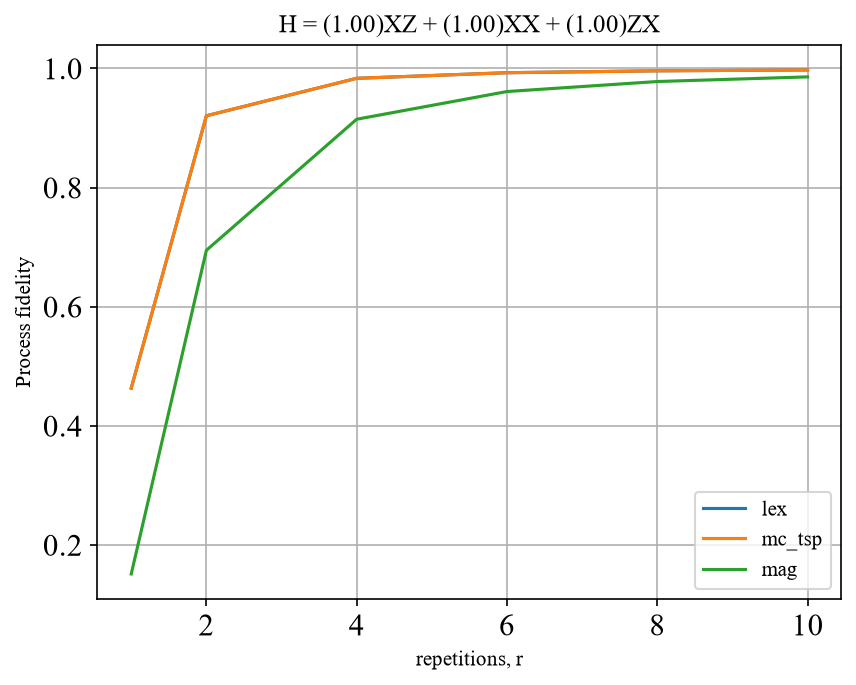

In [16]:
plot(r_vals, [lex_fidelity, mct_fidelity, mag_fidelity], ['lex', 'mc_tsp', 'mag'], H)

In [17]:
H = [(1, 'XZ'), (1, 'XX'), (1, 'ZX'), (1.3, 'ZZ')]
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.41871809e-08 -2.41871809e-08  4.91049967e-08  4.91049967e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [3.91767099e-08 3.91767099e-08 6.35139781e-08 6.35139781e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-3.50556435e-08 -3.50556435e-08  3.73358404e-08  3.73358404e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.74023678e-08 -4.74023678e-08 -4.49839299e-08 -4.49839299e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.29873827e-08 -2.29873827e-08  1.93201366e-08  1.93201366e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-1.91388388e-08 -1.91388388e-08  2.92484231e-08  2.92484231e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [1.38810778e-08 1.38810778e-08 4.91049967e-08 4.91049967e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [3.91767099e-08 3.

lex: [0.0955, 0.5819, 0.8763, 0.9433, 0.9677, 0.9792]
mc_tsp: [0.9313, 0.9899, 0.9977, 0.999, 0.9994, 0.9996]
mag: [0.0185, 0.6399, 0.9346, 0.9735, 0.9856, 0.9909]


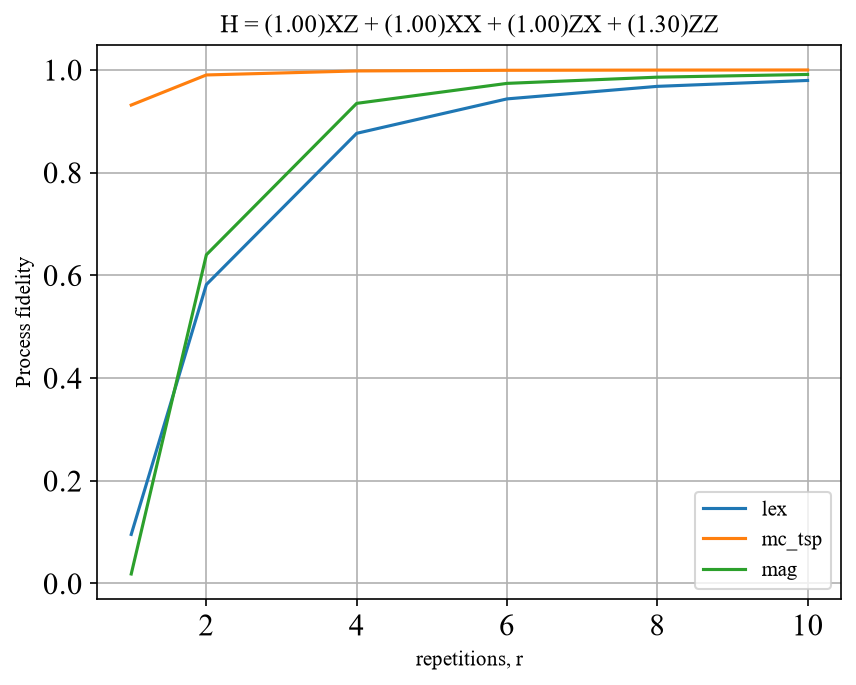

In [18]:
plot(r_vals, fidelities, labels, H)

In [19]:
h0 = get_exact_unitary([(1, 'XZ'), (1, 'XX'), (1, 'ZX'), (1, 'ZZ')])

In [20]:
h1 = np.array(linalg.expm(-1j * get_pauli_sum_op([(1, 'XX'), (1, 'ZZ')]).to_matrix()), dtype=complex)
h2 = np.array(linalg.expm(-1j * get_pauli_sum_op([(1, 'XZ'), (1, 'ZX')]).to_matrix()), dtype=complex)
u1 = h1.dot(h2)

In [21]:
d.processFidelity(h0, u1)

1.0

In [22]:
h0 - u1

array([[-2.22044605e-16+5.55111512e-17j,  1.69714975e-16-1.11022302e-16j,
         3.84896031e-17+5.55111512e-17j, -1.25377210e-16-5.55111512e-17j],
       [-1.69714975e-16+0.00000000e+00j, -1.11022302e-16+0.00000000e+00j,
         9.76216340e-17-1.11022302e-16j,  3.84896031e-17-5.55111512e-17j],
       [ 1.69714975e-16+0.00000000e+00j,  1.79934122e-16+5.55111512e-17j,
        -3.33066907e-16+0.00000000e+00j, -6.62451787e-17-5.55111512e-17j],
       [ 1.90096928e-17-5.55111512e-17j,  1.14203824e-16+1.11022302e-16j,
         3.84896031e-17+5.55111512e-17j, -1.11022302e-16+0.00000000e+00j]])

In [23]:
H = [(0.1, 'XZZ'), (1.2, 'XXZ'), (0.51, 'YZX'), (1.1, 'ZZZ'), (2.0, 'YYY')]
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-7.28748034e-08 -7.28748033e-08 -4.75558202e-08 -4.75558201e-08
  1.04238453e-08  1.04238455e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.64454102e-08 -4.64454102e-08 -2.22522551e-08 -2.22522551e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-1.98786403e-08 -1.98786403e-08  1.87606469e-08  1.87606470e-08
  3.30968193e-08  3.30968193e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.00622989e-08 -5.00622987e-08 -3.68176263e-08 -3.68176261e-08
  2.22707147e-08  2.22707148e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-6.30244018e-08 -6.30244018e-08 -5.58757673e-08 -5.58757672e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-2.29071067e-08 -2.29071066e-08 -1.58375310e-08 -1.58375309e-08
  4.86763102e-08  4.86763102e-08  5.53034645e-08  5.53034645e-08]
Input channel is not TP. Tr_2[Choi] - I has 

lex: [0.0466, 0.5421, 0.8755, 0.9436, 0.9681, 0.9795]
mc_tsp: [0.1049, 0.879, 0.981, 0.9923, 0.9958, 0.9974]
mag: [0.0637, 0.8353, 0.9733, 0.9892, 0.9941, 0.9963]


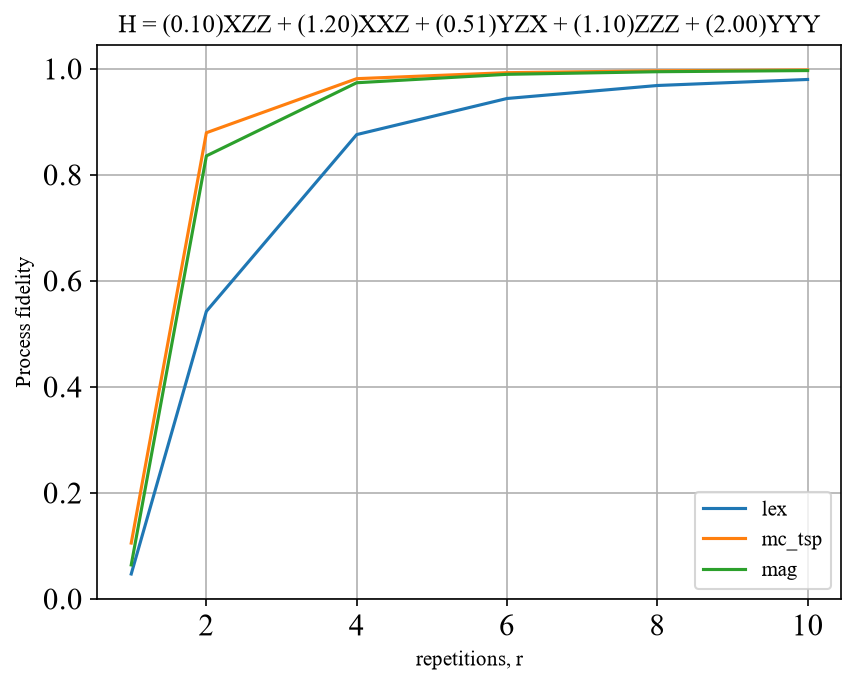

In [24]:
plot(r_vals, fidelities, labels, H)

In [25]:
hams = glob.glob('dqs/hamiltonians/*AS3.txt')
for h in hams:
    print(h)
    nq, H = dqs.hamiltonians.parseHfile(h)
    for term in H:
        print(term[1], end=' ')
    print()

dqs/hamiltonians\1-propanol_sto-3g_BK_NIST_AS3.txt
IIIXXX YIYXXX IIZXXX XYYZXX YXYIXX XYYIXX IIIYYX XZXYYX IZIYYX ZZIYYX XYXZYX XXYIYX IIIXZX IIZXZX IIIYXY YIYYXY IIZYXY XXYZXY XXYIXY YYYIXY IIIXYY XZXXYY IZIXYY ZZIXYY XXXZYY XYYIYY IIIYZY IIZYZY IIIIIZ IIIZXZ YIYZXZ IIZZXZ YZYIXZ YIYIXZ IIZIXZ IZZIXZ ZZZIXZ XYXXYZ XXXYYZ YIXZYZ XZYIYZ IIIIZZ XYYXZZ XXYYZZ IIIZZZ YIYZZZ IIZZZZ XZXIZZ IZIIZZ ZZIIZZ XYYXIZ XXYYIZ IIIZIZ YIYZIZ IIZZIZ XZXIIZ IZIIIZ ZZIIIZ IIIIXI IIIZXI XZXZXI IZIZXI ZZIZXI YIYIXI IIZIXI XXYXYI XYYYYI XZYZYI XZYIYI XIYIYI IIIIZI YXYXZI XYYXZI IXZXZI XXYYZI YYYYZI IYZYZI YZYZZI YIYZZI IIZZZI IZZZZI ZZZZZI YIYIZI IIZIZI XXXXII ZXIXII XYXYII ZYIYII IIIZII XZXZII IZIZII ZZIZII XZXIII XIXIII IZIIII ZZIIII ZIIIII 
dqs/hamiltonians\1-propanol_sto-3g_JW_NIST_AS3.txt
IIYYXX IIXYYX IIIXZX XZXXZX YZYXZX IIZXZX IZIXZX ZIIXZX IXZZZX ZXZZZX IXIZZX IXZIZX IIIXIX IXZZIX IIYXXY IIXXYY IIIYZY XZXYZY YZYYZY IIZYZY IZIYZY ZIIYZY IYZZZY ZYZZZY IYIZZY IYZIZY IIIYIY IYZZIY IIIIIZ IIXZXZ XZZZXZ I

In [26]:
molecule = 'HydrogenPeroxide_sto-3g_JW_NIST_AS2'
_, H = dqs.hamiltonians.parseHfile(f'dqs/hamiltonians/{molecule}.txt')
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.46702469e-08 -4.16462738e-08 -4.16462738e-08 -3.45332437e-08
 -1.45156207e-08  1.64363266e-08  2.46930869e-08  2.46930869e-08
  2.66833506e-08  4.46386940e-08  5.03750675e-08  5.03750679e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.16462738e-08 -4.16462738e-08 -2.49496618e-08 -1.45156207e-08
  1.42752883e-08  2.46930869e-08  2.46930869e-08  2.66833506e-08
  3.72907104e-08  5.03750676e-08  5.03750678e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.16462738e-08 -4.16462738e-08 -3.84124117e-08 -1.45156207e-08
  2.46930869e-08  2.46930869e-08  2.66833506e-08  2.76350437e-08
  3.37121138e-08  3.93476295e-08  5.03750675e-08  5.03750679e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-7.05684437e-08 -4.16462738e-08 -4.16462738e-08 -2.72489496e-08
 -1.78602677e-08 -1.45156207e-08  2.46930869e-08  2.46930869e-08
  2.66833506e-08  3.15998978e-08  

lex: [0.717, 0.915, 0.4123, 0.4744, 0.6136, 0.7181]
mc_tsp: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
mag: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


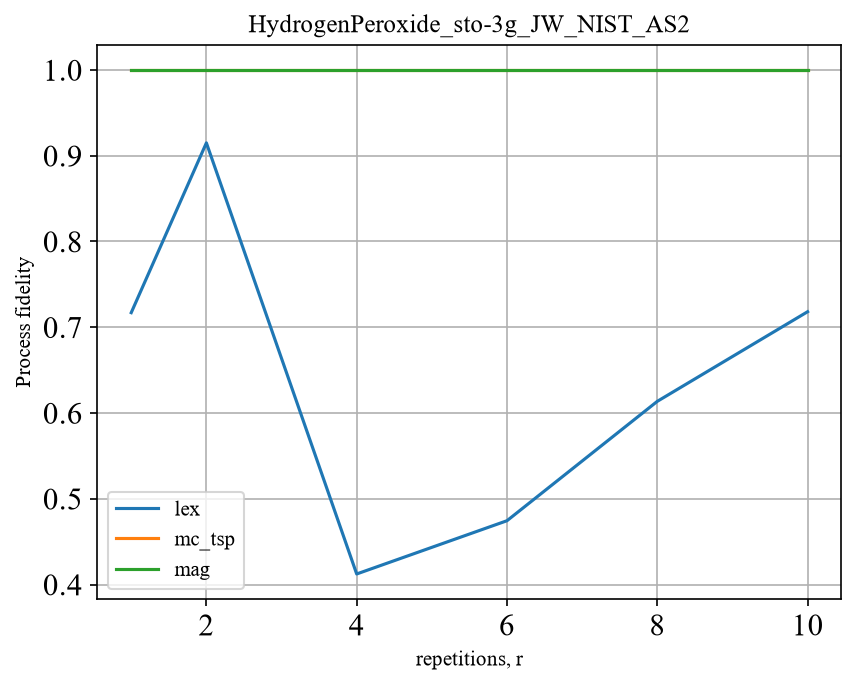

In [27]:
plot(r_vals, fidelities, labels, H, title=molecule)

In [28]:
nq = 5
nt = 14
H = dqs.hamiltonians.random_H(nq, nt)
r_vals = [1, 2, 4, 6, 8, 10]
labels = ['lex', 'mc_tsp', 'mag', 'rand']
fidelities = []
for label in labels:
    fidelities.append(fidelity_over_r(H, label, r_vals))

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-6.17711671e-08 -5.44123820e-08 -4.98973942e-08 -4.65997152e-08
 -4.42287596e-08 -4.02960563e-08 -3.41110539e-08 -3.25539321e-08
 -2.84306711e-08 -2.65478117e-08 -2.15658510e-08 -1.96833309e-08
 -1.28940469e-08  1.53929944e-08  1.66883616e-08  2.11467723e-08
  2.57959522e-08  2.93959321e-08  3.53881576e-08  3.85025278e-08
  4.39931862e-08  4.61173595e-08  4.94315858e-08  5.29198604e-08
  5.99171563e-08  6.75669328e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-7.12068143e-08 -6.68177198e-08 -5.55876151e-08 -4.96912635e-08
 -4.78955415e-08 -4.32067071e-08 -4.09448726e-08 -3.59886922e-08
 -3.15875161e-08 -2.65871506e-08 -2.23350343e-08 -1.87931664e-08
 -1.55061062e-08 -1.09099820e-08  1.42369344e-08  1.69589687e-08
  2.14732638e-08  2.47374025e-08  2.94559712e-08  3.38833970e-08
  3.93635874e-08  4.32574512e-08  5.10334687e-08  5.40382495e-08
  5.77183846e-08  6.58038763e-08]
Input channel is not

lex: [0.0014, 0.1649, 0.69, 0.8525, 0.9151, 0.9451]
mc_tsp: [0.0003, 0.2225, 0.7578, 0.891, 0.9386, 0.9607]
mag: [0.0006, 0.1742, 0.7154, 0.8672, 0.9241, 0.9511]
rand: [0.0018, 0.1829, 0.7123, 0.8636, 0.9214, 0.9491]


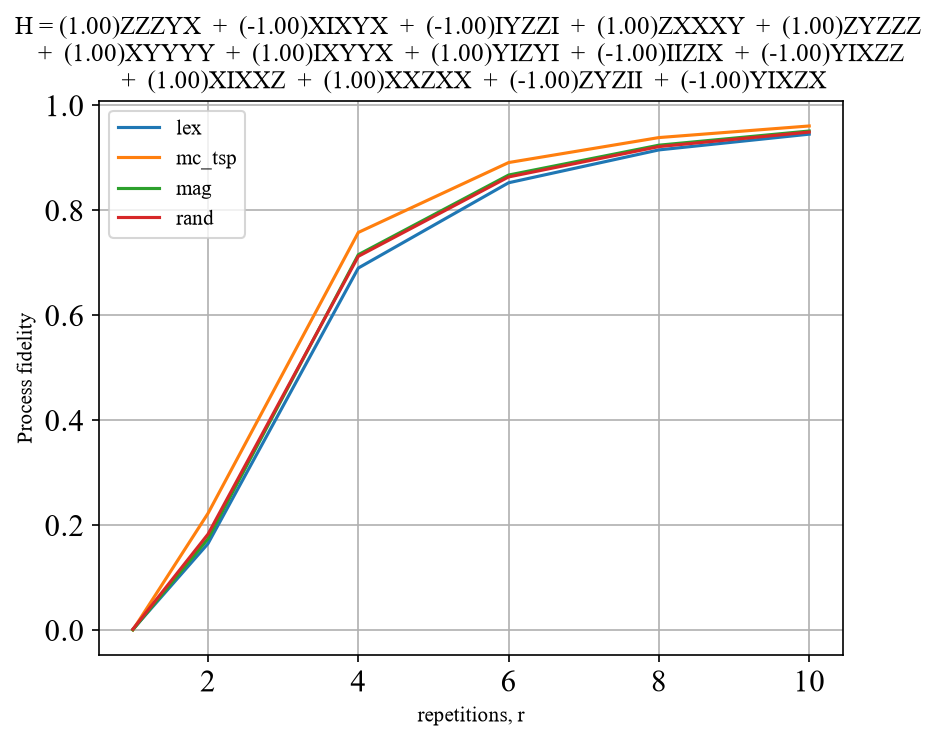

In [29]:
plot(r_vals, fidelities, labels, H)

# Energy and Reaction Rates

In [30]:
def trotter_time_simulation(dqs_obj, Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01, r=1):
    expectations = []
    process_fidelity = []
    diamond_distance = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        curH = Hfunc(t)
        dqs_obj.update_coefficients([(term[1], term[0]) for term in curH])
        dqs_obj.gen_circuit(t=t, r=r)
        evolution_unitary = dqs_obj.getCircuitUnitary()
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)

        exact_unitary = get_exact_unitary(curH, t)
        process_fidelity.append(dqs_obj.processFidelity(exact_unitary, evolution_unitary))
        diamond_distance.append(dqs_obj.diamondNorm(exact_unitary, evolution_unitary))
    return expectations, time, process_fidelity, diamond_distance


In [31]:
nq = 3
gamma = 3.14 / 2
H = [('IIX', gamma), ('IXI', gamma), ('XII', gamma)]

init_state = Statevector.from_int(0, int(2**nq))
print(init_state)

meas_op = get_pauli_sum_op([(1.0, 'IIZ'), (1.0, 'IZI'), (1.0, 'ZII')])

expectations, time = time_simulation(H, init_state, meas_op)

fig, ax = plt.subplots(dpi=150)
ax.plot(time, expectations)


Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


TypeError: 'list' object is not callable

               
q_0: ──■───────
     ┌─┴─┐     
q_1: ┤ X ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘
3.0


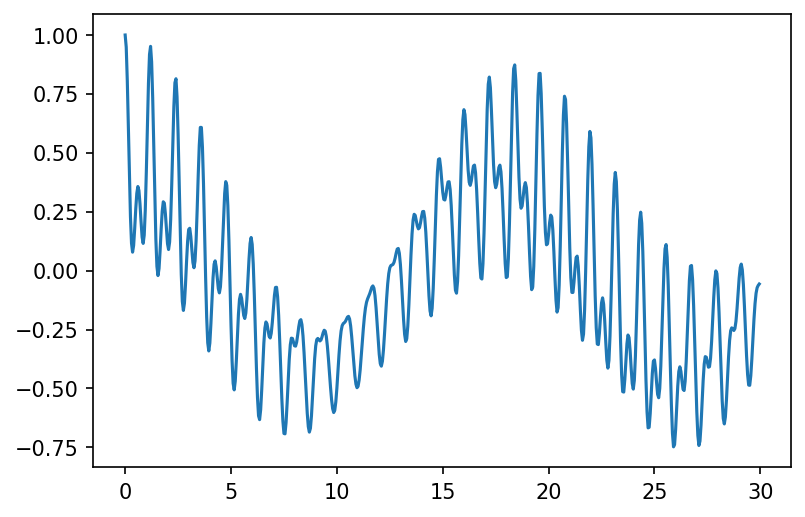

In [ ]:
nq = 3
mu = -5
interaction = -1
H = [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), ('IIX', 0.2), ('XII', 0.5*mu), ('IXI', 1.0*mu)]

init_circ = QuantumCircuit(nq)
init_circ.cx(0,1)
init_circ.cx(1,2)
init_state = Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = SparsePauliOp.from_list([('ZII', gamma), ('IZI', gamma), ('IIZ', gamma)])

print(init_state.expectation_value(meas_op).real)

expectations, time = time_simulation(H, init_state, meas_op, tend=30, tstep=0.05)
fig, ax = plt.subplots(dpi=150)
ax.plot(time, [expval / nq for expval in expectations])


[('YYXX', -0.5270026512078708), ('XYYX', 0.5270026512078708), ('YXXY', 0.5270026512078708), ('XXYY', -0.5270026512078708), ('IIIZ', 6.982922762997513), ('IIZZ', 0.6596700942103038), ('IZIZ', 0.1323827348627502), ('ZIIZ', 0.659385386070621), ('IIZI', 6.9829227629975135), ('IZZI', 0.659385386070621), ('ZIZI', 0.1323827348627502), ('IZII', 6.983973664851903), ('ZZII', 0.6591013784303086), ('ZIII', 6.983973664851903)]
     
q_0: 
     
q_1: 
     
q_2: 
     
q_3: 
     


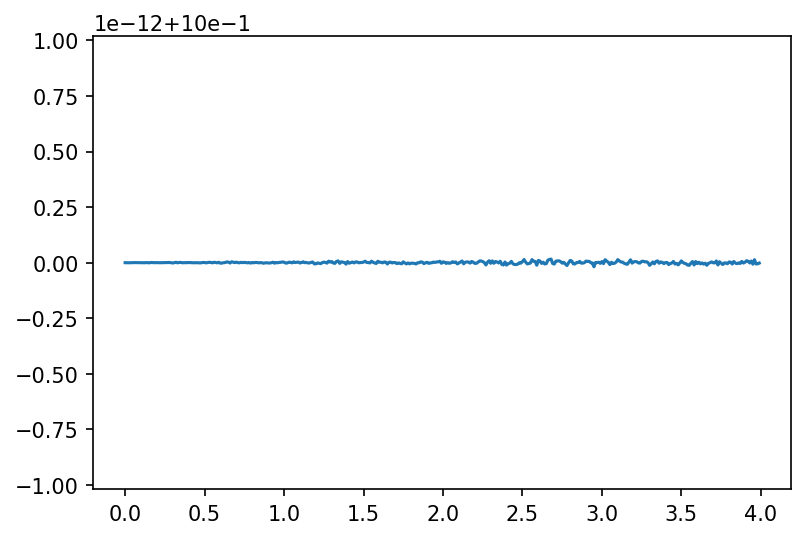

In [ ]:
molecule = 'HydrogenPeroxide_sto-3g_JW_NIST_AS2'
nq = 4
_, H = dqs.hamiltonians.parseHfile(f'dqs/hamiltonians/{molecule}.txt')
H = [(term[1], term[0]) for term in H]
print(H)

init_circ = QuantumCircuit(nq)
print(init_circ)
init_state = Statevector.from_instruction(init_circ)
meas_op = SparsePauliOp.from_list([('IIIZ', 1), ('IIZI', 1), ('IZII', 1), ('ZIII', 1)])

expectations, time = time_simulation(H, init_state, meas_op)
fig, ax = plt.subplots(dpi=150)
ax.plot(time, [expval / nq for expval in expectations])


# Trotterization approximations to Ising Model

In [ ]:
nq = 3

def hamiltonian(t):
    omega = np.pi
    epsilon = -1
    interaction = -1
    factor = epsilon * np.cos(omega * t)
    return [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), ('IIX', factor), ('XII', factor), ('IXI', factor)]

init_circ = QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = SparsePauliOp.from_list([('ZII', 1), ('IZI', 1), ('IIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)

results = [('Exact', exact_expectations, times, [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    expectations, time, process_fidelity = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)
    results.append((sort_type.upper(), expectations, time, process_fidelity))
print('done')


     
q_0: 
     
q_1: 
     
q_2: 
     
Exact results...


NameError: name 'time_simulation' is not defined

Text(0.5, 0, 'Time')

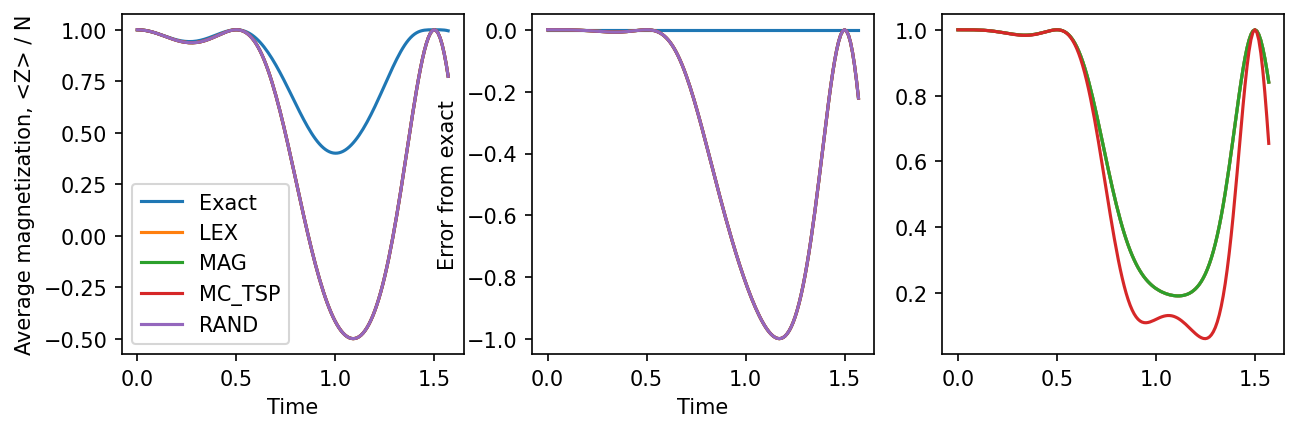

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, dpi=150, figsize=[10,3])
exact_results = results[0][1]
for i, (label, expectations, time, pfids) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if len(pfids) == len(time):
        ax[2].plot(time, pfids, label=label)
ax[0].legend()
ax[0].set_ylabel('Average magnetization, <Z> / N')
ax[0].set_xlabel('Time')
ax[1].set_ylabel('Error from exact')
ax[1].set_xlabel('Time')

In [ ]:
nq = 4

random_hamiltonian = dqs.hamiltonians.random_H(nq, 50, binary=False)
print(random_hamiltonian)

def hamiltonian(t):
    return [(term[1], term[0]) for term in random_hamiltonian]

init_circ = QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = SparsePauliOp.from_list([('ZIII', 1), ('IZII', 1), ('IIZI', 1), ('IIIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=1, tstep=0.02)

results = [('Exact', exact_expectations, times, [], [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    simresult = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=1, tstep=0.02)
    results.append((sort_type.upper(), *simresult))
print('done')


[(-0.7996119315136793, 'IIXI'), (-0.42391387022729843, 'YIIZ'), (-0.6998223832832711, 'IXYX'), (0.3849268041579499, 'YXYI'), (-0.16106270772279593, 'YZXX'), (-0.9158862188867077, 'ZYZZ'), (0.8377255811516323, 'YZII'), (-0.3834990885202051, 'ZZXX'), (0.21269486624441136, 'IIXX'), (-0.8050716755523422, 'IXYZ'), (0.23590927960774866, 'IZIX'), (-0.4937020733076797, 'YXXX'), (-0.9851037126469128, 'XIXY'), (0.9307421167934103, 'YZIX'), (-0.46769049985230715, 'ZXYY'), (0.5145272868915529, 'XZYI'), (-0.38332970769701746, 'ZXZX'), (-0.707099155675912, 'XIZZ'), (-0.7950130726091146, 'ZZXY'), (-0.8084773702284218, 'YZYI'), (-0.8612352698069474, 'ZZXZ'), (-0.2843222580325675, 'ZIXZ'), (0.6561739885913553, 'XYXZ'), (-0.354904066601052, 'ZXII'), (0.43295844423680874, 'YXYX'), (0.45595753009543494, 'IZIY'), (0.7996122507985404, 'IIYX'), (0.6600306144082835, 'ZIXY'), (0.28748570677366425, 'IYII'), (0.45237805153483945, 'YXII'), (-0.8005179384411137, 'ZZXI'), (0.7981108234383582, 'XYIY'), (0.4089772271

Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.44514977e-08 -5.32415187e-08 -4.99344486e-08 -4.54042020e-08
 -3.70238945e-08 -3.10277124e-08 -2.10880968e-08 -1.75477582e-08
  1.60665808e-08  1.72354235e-08  2.55512487e-08  4.71969304e-08
  5.82428697e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.56638683e-08 -3.65872770e-08 -3.34287216e-08 -1.36095751e-08
 -1.00439455e-08  1.97836847e-08  2.52949629e-08  3.38794271e-08
  3.78617681e-08  4.55127366e-08  5.39447111e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.23276096e-08 -3.69769260e-08 -3.32001486e-08  1.19981064e-08
  1.43323909e-08  1.92259123e-08  3.38699963e-08  4.15220545e-08
  4.44018040e-08  4.60983421e-08  5.08452316e-08  5.52225120e-08
  5.68759588e-08  6.50147771e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-6.55397066e-08 -5.85323094e-08 -5.22084234e-08 -4.65342439e-08
 -2.90033127e-08 -1.91692704e-08  1.82653792e-08 

MAG results...


Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.79461867e-08 -5.46267281e-08 -5.41742672e-08 -5.10243943e-08
 -4.96294296e-08 -3.69242438e-08 -3.20364513e-08  1.24518642e-08
  2.61513086e-08  5.15190481e-08  5.55935435e-08  5.75243664e-08
  5.97918536e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.73981065e-08 -5.13194073e-08 -3.76098514e-08 -3.56102192e-08
 -1.35166097e-08  1.84307846e-08  3.21627997e-08  3.54501797e-08
  3.76131743e-08  4.10827183e-08  4.56132011e-08  5.21381301e-08
  5.56711049e-08  5.85038327e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.93173062e-08 -4.85074525e-08 -4.19397020e-08 -3.74863083e-08
 -3.21928199e-08 -2.88221443e-08 -1.45456485e-08  1.18108470e-08
  2.11734550e-08  4.02717918e-08  5.79982452e-08  5.98931161e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.86625832e-08 -4.61205354e-08 -4.15134408e-08 -3.64651082e-08
 -3.15636142e-08 -2.85981256e-08 

MC_TSP results...


...

RAND results...


Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.77740246e-08 -5.62976236e-08 -4.55127226e-08 -4.06965718e-08
 -3.92840057e-08 -2.93751682e-08 -2.69409710e-08 -2.30241921e-08
 -1.92715670e-08  1.10482121e-08  1.85624209e-08  4.44926625e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.67230991e-08 -5.57416650e-08 -5.38706434e-08 -3.02731277e-08
 -1.82587620e-08 -1.52368629e-08  2.29751532e-08  2.78491625e-08
  3.92573157e-08  4.24567184e-08  4.85762419e-08  5.91137541e-08
  6.04537190e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.52564033e-08 -4.89222558e-08 -4.16373912e-08 -3.41754796e-08
 -3.19390444e-08 -2.31926800e-08 -1.24089233e-08  1.44064199e-08
  2.60702407e-08  4.01338099e-08  4.24627194e-08  5.17455399e-08
  5.94359336e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.20036724e-08 -4.01393965e-08 -3.08573420e-08  1.22748041e-08
  1.93472189e-08  2.62051643e-08  3.17699828e-08 

DEPLETEGROUPS results...


Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.92409990e-08 -5.84557860e-08 -5.01886321e-08 -4.40417744e-08
 -4.00740889e-08 -3.29060423e-08 -3.06264736e-08 -2.91970124e-08
 -2.44935648e-08 -2.03077743e-08 -1.81328504e-08 -1.53667480e-08
 -1.00196674e-08  1.60382734e-08  2.31893090e-08  4.26792464e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-5.66373172e-08 -5.20532369e-08 -3.21453391e-08 -2.53565641e-08
 -2.25282413e-08 -2.16326711e-08 -1.63993452e-08 -1.15564497e-08
  1.17890812e-08  1.63173399e-08  2.93383708e-08  3.39406523e-08
  4.70634232e-08  5.14639949e-08  5.48287854e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [-4.56734084e-08 -3.82150772e-08 -3.28525581e-08 -2.54462773e-08
 -1.97665111e-08 -1.23631831e-08 -1.06790183e-08  1.09612805e-08
  1.82680229e-08  1.99558954e-08  2.64056351e-08  3.04843237e-08
  4.74972371e-08  4.88170524e-08]
Input channel is not TP. Tr_2[Choi] - I has non-zero eigenvalues: [

done


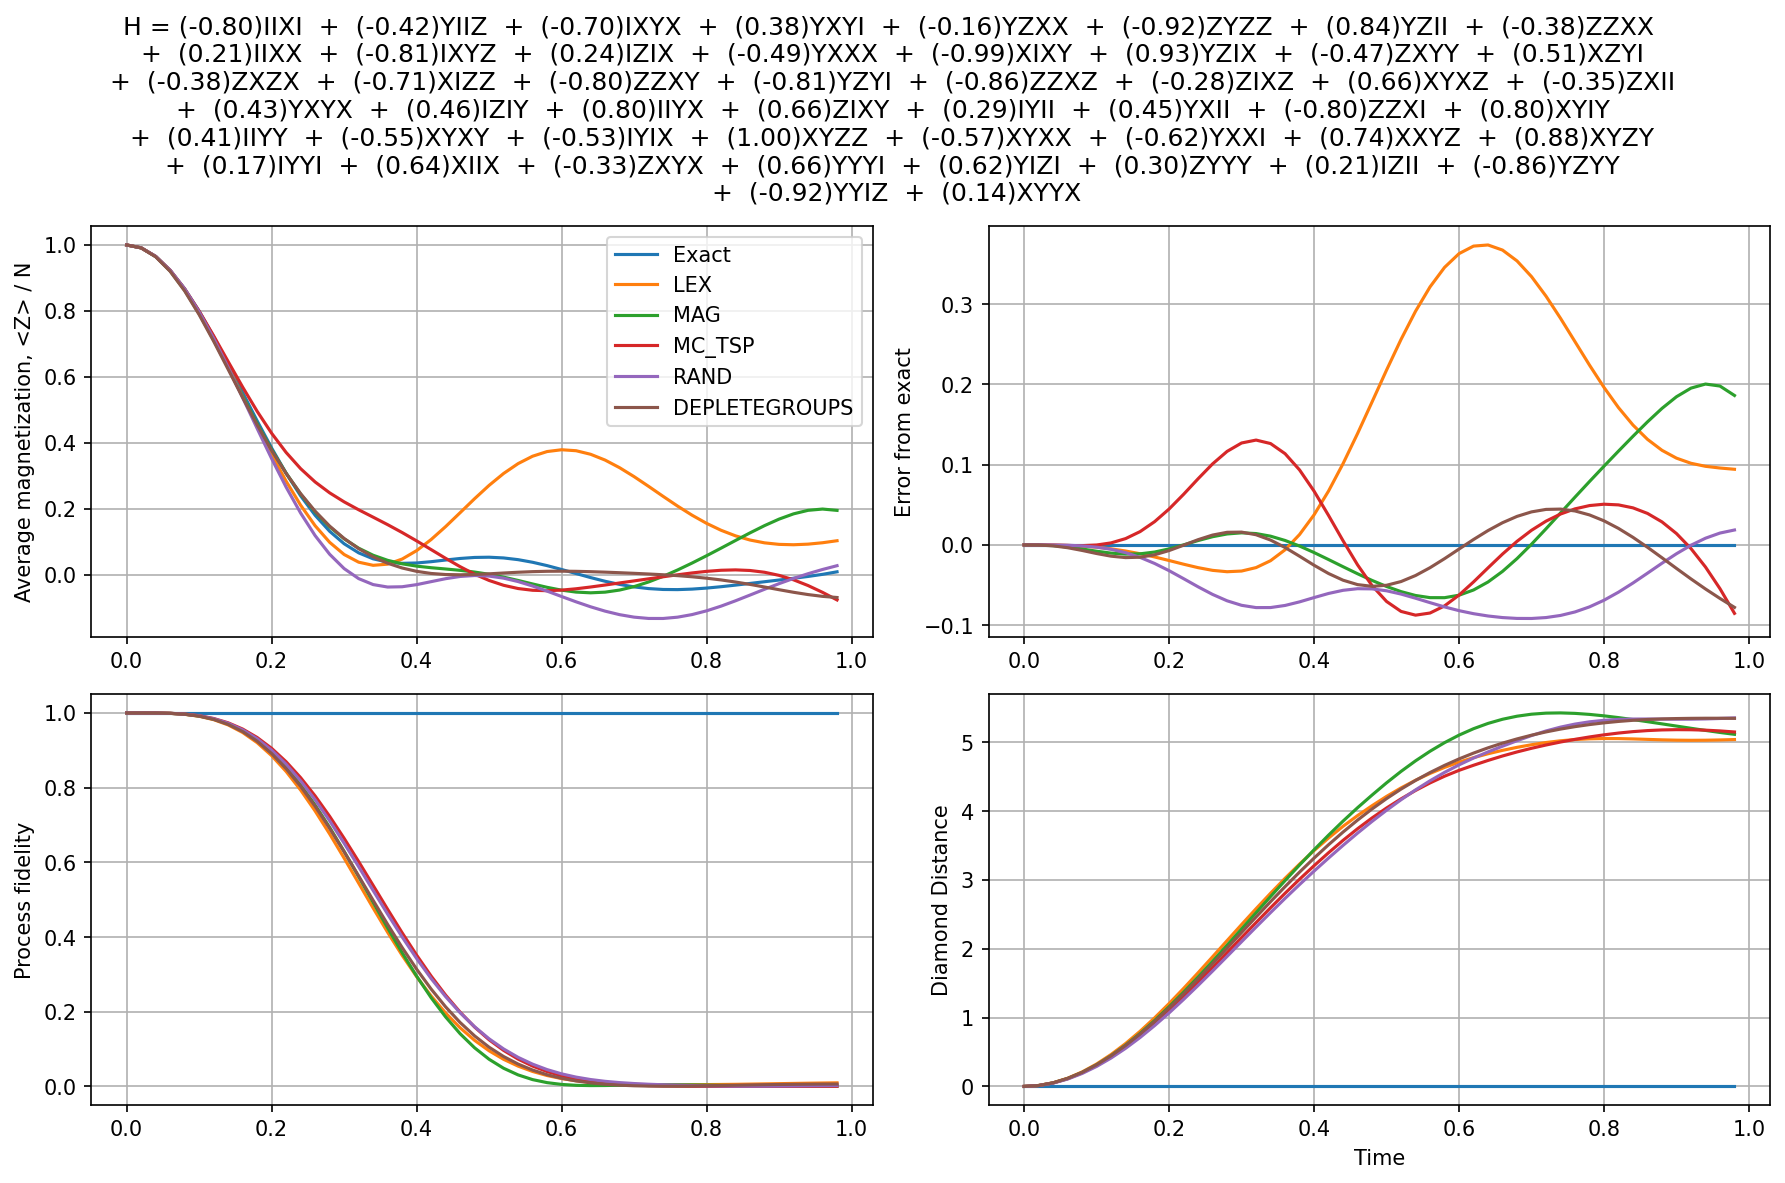

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, dpi=150, figsize=[12,8])
exact_results = results[0][1]
for i, (label, expectations, time, pfids, diamond_dists) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0][0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[0][1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if label == 'Exact':
        pfids = [1]*len(time)
        diamond_dists = [0]*len(time)
    ax[1][0].plot(time, pfids, label=label)
    ax[1][1].plot(time, diamond_dists, label=label)
ax[0][0].legend()
ax[0][0].set_ylabel('Average magnetization, <Z> / N')
ax[0][1].set_ylabel('Error from exact')
ax[1][0].set_ylabel('Process fidelity')
ax[1][1].set_ylabel('Diamond Distance')
for i, row in enumerate(ax):
    for axis in row:
        axis.grid()
    if i == 1:
        axis.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str([(term[1], term[0]) for term in hamiltonian(0)], sigfigs=2)
harray = hstr.split('+')
if len(harray) > 8:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 8:
            hstr += '\n'
            i = 0
fig.suptitle('H = ' + hstr)
plt.tight_layout()
#plt.savefig('figures/random-binary-hamiltonian_2.pdf')

In [ ]:
def reach_epsilon(t, epsilon, dqs_obj, r_limit=10):
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    cur_epsilon = 100
    r = 0
    while cur_epsilon > epsilon and r < r_limit:
        r += 1
        dqs_obj.gen_circuit(t=t, r=r)
        Uapprox = dqs_obj.getCircuitUnitary()
        cur_epsilon = dqs_obj.diamondNorm(Uexact, Uapprox)
    
    if r >= r_limit:
        print(f"Unable to achieve epsilon <= {epsilon} with r <= {r_limit}")
        return -1, r, -1
    
    cnot_cost = dqs_obj.total_cnot_count(r=r)
    
    return cur_epsilon, r, cnot_cost

In [ ]:
num_qubits = 4
num_terms = 20
epsilon_limit = 0.2

hamiltonian = dqs.hamiltonians.random_H(num_qubits, num_terms, binary=True)
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

[(-1, 'YIXY'), (-1, 'ZXXI'), (1, 'ZYIZ'), (-1, 'IYIX'), (-1, 'IYXZ'), (1, 'IIXY'), (1, 'XXXZ'), (1, 'YZIZ'), (1, 'XZYX'), (1, 'XZYZ'), (-1, 'YYXX'), (-1, 'XXXX'), (-1, 'ZZXY'), (1, 'YZZX'), (1, 'XXZI'), (1, 'IXZI'), (-1, 'XYZX'), (-1, 'IXZX'), (-1, 'YYIZ'), (-1, 'IIYY')]
LEX results...
Unable to achieve epsilon <= 0.2 with r <= 12
MAG results...
Unable to achieve epsilon <= 0.2 with r <= 12
MC_TSP results...
Unable to achieve epsilon <= 0.2 with r <= 12
RAND results...
Unable to achieve epsilon <= 0.2 with r <= 12
DEPLETEGROUPS results...
Unable to achieve epsilon <= 0.2 with r <= 12
done


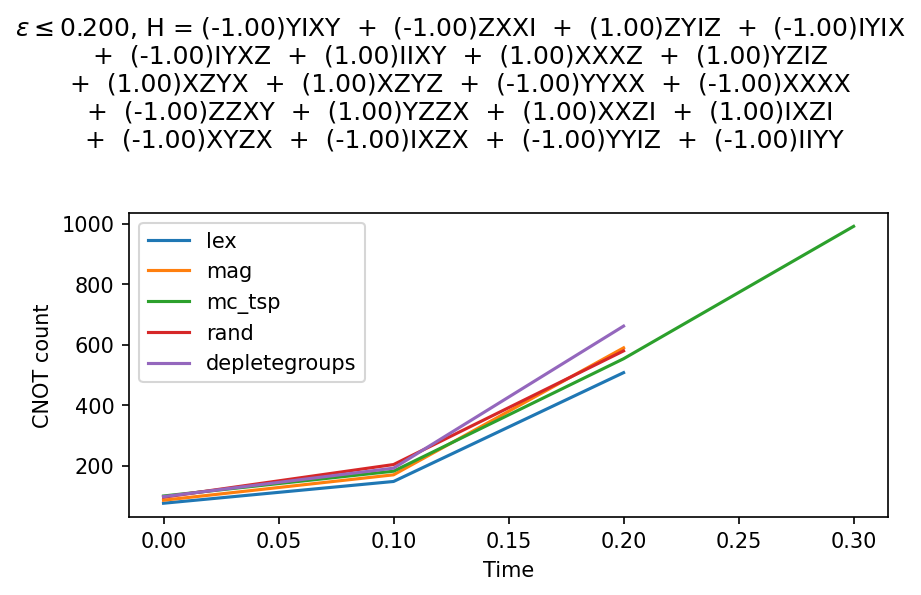

In [ ]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str(hamiltonian, sigfigs=2)
harray = hstr.split('+')
if len(harray) > 4:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 4:
            hstr += '\n'
            i = 0
fig.suptitle(r'$\epsilon \leq {:.3f}$, H = {}'.format(epsilon_limit, hstr))
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
epsilon_limit = 0.2
molecule = 'Methylamine_sto-3g_JW_NIST_AS2'
hamiltonian = dqs.quantum_dynamics.Dynamics(f'dqs/hamiltonians/{molecule}.txt')._getH_without_groups()
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

[(-1.8577463854703422e-07, 'YYXX'), (1.8577463854703422e-07, 'XYYX'), (-0.0005318575142158455, 'IXZX'), (0.00011851141427133297, 'ZXZX'), (0.00019351067740563894, 'IXIX'), (1.8577463854703422e-07, 'YXXY'), (-1.8577463854703422e-07, 'XXYY'), (-0.0005318575142158455, 'IYZY'), (0.00011851141427133297, 'ZYZY'), (0.00019351067740563894, 'IYIY'), (3.3017623766914292, 'IIIZ'), (0.00019351067740563894, 'XZXZ'), (0.00019351067740563894, 'YZYZ'), (1.0317057101813696, 'IIZZ'), (0.09031383437777553, 'IZIZ'), (0.09031402015241408, 'ZIIZ'), (-0.0005318575142158454, 'XZXI'), (0.00011851141427133298, 'XIXI'), (-0.0005318575142158454, 'YZYI'), (0.00011851141427133298, 'YIYI'), (3.3017623766914292, 'IIZI'), (0.09031402015241408, 'IZZI'), (0.09031383437777553, 'ZIZI'), (1.0528741030160065, 'IZII'), (0.8754243524090393, 'ZZII'), (1.0528741030160065, 'ZIII')]
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done


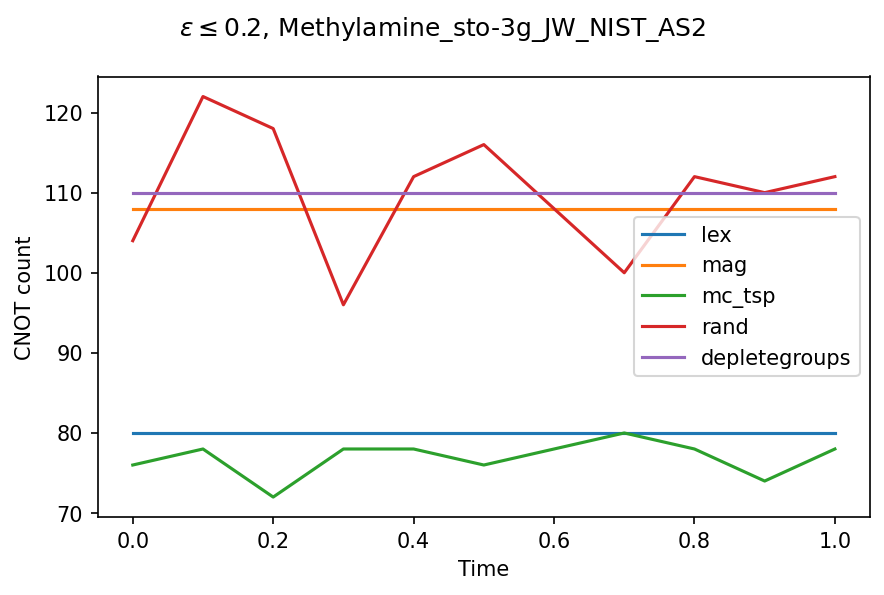

In [ ]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
fig.suptitle(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
glob.glob('dqs/hamiltonians/*AS2.txt')

['dqs/hamiltonians/Cl2_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/EthanoicAcid_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/O2_sto-3g_JW_NIST_singlet_AS2.txt',
 'dqs/hamiltonians/SodiumHydroxide_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/Methane_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/HCl_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/SodiumHydride_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/Ethene_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/Hydroxide_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/LithiumHydroxide_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/HCl_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/Ethanal_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/HF_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/Ethanal_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/Ammonia_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians/Methanol_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/Cl2_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/MagnesiumDihydride_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians/Ethanamide_sto-3g_JW_N

In [ ]:
epsilon_limit = 0.2
for fn in glob.glob('dqs/hamiltonians/*AS2.txt'):
    molecule = fn.split('/')[-1][:-4]
    hamiltonian = dqs.quantum_dynamics.Dynamics(fn)._getH_without_groups()
    print(molecule)

    results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
    for sort_type in results.keys():
        print(f'{sort_type.upper()} results...')
        for t in np.arange(0, 1.1, 0.1):
            dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
            dqs_obj.sort_hamiltonian(sort_type)
            simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
            if simresult[0] == -1:
                break
            results[sort_type].append((t, *simresult))
    print('done')

    fig, ax = plt.subplots(dpi=150)

    for label, result in results.items():
        time, diamond_dist, r_needed, gate_count = [], [], [], []
        for val in result:
            if val[1] < 0:
                break
            time.append(val[0])
            diamond_dist.append(val[1])
            r_needed.append(val[2])
            gate_count.append(val[3])

        ax.plot(time, gate_count, label=label)

    ax.legend()
    ax.set_ylabel('CNOT count')
    ax.set_xlabel('Time')
    ax.set_title(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
    plt.tight_layout()
    plt.savefig(f'figures/molecular_hamiltonians_epsilon_limit/{molecule}_epsilon{epsilon_limit}.pdf')
    plt.close()

Cl2_sto-3g_JW_NIST_AS2
LEX results...
Unable to achieve epsilon <= 0.2 with r <= 12
MAG results...
MC_TSP results...
RAND results...
Unable to achieve epsilon <= 0.2 with r <= 12
DEPLETEGROUPS results...
Unable to achieve epsilon <= 0.2 with r <= 12
done
EthanoicAcid_sto-3g_JW_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
O2_sto-3g_JW_NIST_singlet_AS2
LEX results...
Unable to achieve epsilon <= 0.2 with r <= 12
MAG results...
MC_TSP results...
RAND results...
Unable to achieve epsilon <= 0.2 with r <= 12
DEPLETEGROUPS results...
Unable to achieve epsilon <= 0.2 with r <= 12
done
SodiumHydroxide_sto-3g_BK_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
Methane_sto-3g_JW_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
HCl_sto-3g_BK_NIST_AS2
LEX results...
Unable to achieve epsilon <= 0.2 with r <= 12
MAG results...
Unable t

/home/ttomesh/qenv/lib/python3.8/site-packages/cvxpy/problems/problem.py:1278: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


MAG results...
MC_TSP results...
RAND results...
Unable to achieve epsilon <= 0.2 with r <= 12
DEPLETEGROUPS results...
Unable to achieve epsilon <= 0.2 with r <= 12
done
Hydroxide_sto-3g_BK_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
LithiumHydroxide_sto-3g_BK_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
HCl_sto-3g_JW_NIST_AS2
LEX results...
Unable to achieve epsilon <= 0.2 with r <= 12
MAG results...
Unable to achieve epsilon <= 0.2 with r <= 12
MC_TSP results...
Unable to achieve epsilon <= 0.2 with r <= 12
RAND results...
Unable to achieve epsilon <= 0.2 with r <= 12
DEPLETEGROUPS results...
Unable to achieve epsilon <= 0.2 with r <= 12
done
Ethanal_sto-3g_JW_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results...
done
HF_sto-3g_BK_NIST_AS2
LEX results...
MAG results...
MC_TSP results...
RAND results...
DEPLETEGROUPS results.

# Plot Gate Cost Simulations

In [ ]:
pickles = glob.glob('dqs/benchmark_results/gate_cost_simulation/4qubit_epsilon0.1/*pickle')
print(len(pickles))

79


In [ ]:
all_data = {key: [] for key in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']}
for pklfile in pickles:
    with open(pklfile, 'rb') as pf:
        result = pickle.load(pf)
        for key in result.keys():
            all_data[key].append(result[key])

In [ ]:
all_data

{'lex': [[(0.0, 0.0, 1, 38)],
  [(0.0, 0.0, 1, 80),
   (0.1, 0.006082, 1, 80),
   (0.2, 0.024807, 1, 80),
   (0.30000000000000004, 0.05733, 1, 80),
   (0.4, 0.038426, 2, 160),
   (0.5, 0.052768, 2, 160),
   (0.6000000000000001, 0.065922, 2, 160),
   (0.7000000000000001, 0.076685, 2, 160),
   (0.8, 0.09008, 2, 160),
   (0.9, 0.055294, 3, 240),
   (1.0, 0.063369, 3, 240)],
  [(0.0, 0.0, 1, 80),
   (0.1, 0.011594, 1, 80),
   (0.2, 0.04968, 1, 80),
   (0.30000000000000004, 0.036592, 2, 160),
   (0.4, 0.05153, 2, 160),
   (0.5, 0.059796, 2, 160),
   (0.6000000000000001, 0.07936, 2, 160),
   (0.7000000000000001, 0.060627, 3, 240),
   (0.8, 0.094003, 3, 240),
   (0.9, 0.074908, 4, 320),
   (1.0, 0.095426, 4, 320)],
  [(0.0, 0.0, 1, 80),
   (0.1, 0.094251, 3, 240),
   (0.2, 0.099916, 5, 400),
   (0.30000000000000004, 0.065011, 6, 480),
   (0.4, 0.092507, 13, 1040),
   (0.5, 0.089215, 12, 960),
   (0.6000000000000001, 0.099615, 13, 1040)],
  [(0.0, 0.0, 1, 80), (0.1, 0.078777, 4, 320), (0.2, 0.

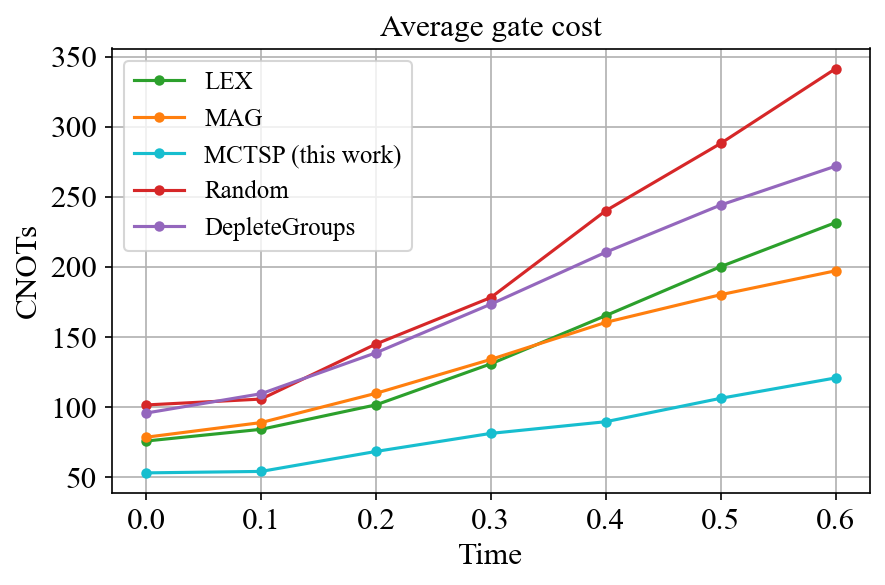

In [ ]:
fig, ax = plt.subplots(dpi=150)

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP (this work)', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(cnot_dict[t]) for t in times]
    stdevs = [np.std(cnot_dict[t]) for t in times]
    maxs = [np.max(cnot_dict[t]) for t in times]
    mins = [np.min(cnot_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]
    #y1 = maxs
    #y2 = mins
    #ax.fill_between(times, y1, y2, alpha=0.1)
ax.legend(fontsize=12)
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('CNOTs', fontsize=15)
ax.set_title(r'Average gate cost', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_cnot.pdf')

In [ ]:
for key in plotted_vals.keys():
    if key == 'mc_tsp':
        continue
    
    percent_reducs = [(other_val - mctsp_val) / other_val for other_val, mctsp_val in zip(plotted_vals[key], plotted_vals['mc_tsp'])]
    print(f'Average reduction in gate count between {key} -> mc_tsp = {np.mean(percent_reducs) * 100:.3f}%')

Average reduction in gate count between lex -> mc_tsp = 39.513%
Average reduction in gate count between mag -> mc_tsp = 38.912%
Average reduction in gate count between rand -> mc_tsp = 56.275%
Average reduction in gate count between depletegroups -> mc_tsp = 52.608%


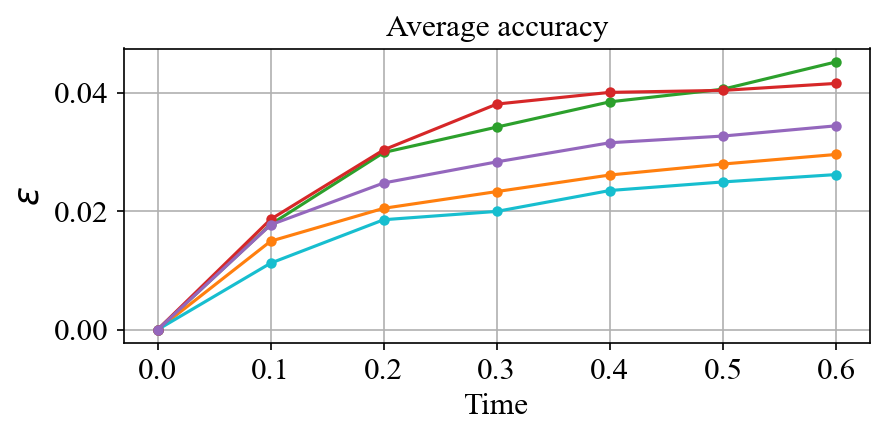

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(epsilon_dict[t]) for t in times]
    stdevs = [np.std(epsilon_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.axhline(y=0.1, color='k', ls='--')
ax.grid()
#ax.legend()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel(r'$\epsilon$', fontsize=17)
ax.set_title(r'Average accuracy', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_accuracy.pdf')    

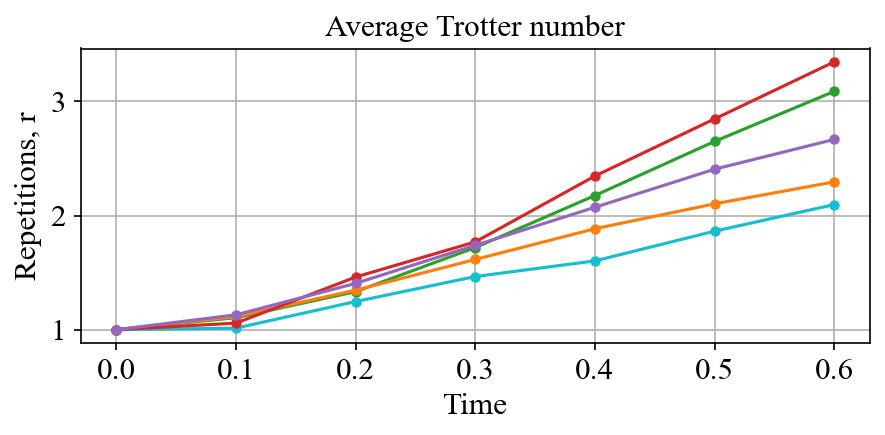

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(rval_dict[t]) for t in times]
    stdevs = [np.std(rval_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=sort_type, fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.legend()
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('Repetitions, r', fontsize=15)
ax.set_title(r'Average Trotter number', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_r.pdf')

In [ ]:
molecules = ['Ethene_sto-3g_BK_NIST_AS2.txt', 'Cl2_sto-3g_JW_NIST_AS2.txt', 'Ethyne_sto-3g_JW_NIST_AS2.txt',
             'F2_sto-3g_JW_NIST_AS2.txt', 'N2_sto-3g_JW_NIST_AS2.txt', 'O2_sto-3g_BK_NIST_triplet_AS2.txt']
t = 1
for molecule in molecules:
    print(molecule)
    dqs_obj = dqs.quantum_dynamics.Dynamics('dqs/hamiltonians/' + molecule)
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    for sort_type in ['lex', 'mag', 'mc_tsp']:
        dqs_obj.sort_hamiltonian(sort_type)
        dqs_obj.gen_circuit(t=t, r=1)
        Uapprox = dqs_obj.getCircuitUnitary()
        diamond_norm = dqs_obj.diamondNorm(Uexact, Uapprox)
        print(f'\t{sort_type} diamond norm = {diamond_norm}')

Ethene_sto-3g_BK_NIST_AS2.txt
	lex diamond norm = 2.935553
	mag diamond norm = 0.001804
	mc_tsp diamond norm = 0.001804
Cl2_sto-3g_JW_NIST_AS2.txt
	lex diamond norm = 1.936416
	mag diamond norm = 0.000136
	mc_tsp diamond norm = 0.000136
Ethyne_sto-3g_JW_NIST_AS2.txt
	lex diamond norm = 1.939977
	mag diamond norm = 0.001291
	mc_tsp diamond norm = 0.001291
F2_sto-3g_JW_NIST_AS2.txt
	lex diamond norm = 1.116098
	mag diamond norm = 0.002951
	mc_tsp diamond norm = 0.002951
N2_sto-3g_JW_NIST_AS2.txt
	lex diamond norm = 1.657505
	mag diamond norm = 0.001166
	mc_tsp diamond norm = 0.001166
O2_sto-3g_BK_NIST_triplet_AS2.txt
	lex diamond norm = 3.090414
	mag diamond norm = 0.00405
	mc_tsp diamond norm = 0.00405
